<a href="https://colab.research.google.com/github/kkhand3/fair-taxation-of-EVs-in-MN/blob/main/EV_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning and Manipulation

In [ ]:
#installing libraries
!pip install playwright pandas
!playwright install chromium
!playwright install-deps chromium
!pip install gdown

Installing dependencies...
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 388 kB in 1s (323 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Don

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import asyncio
import re
import time
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from io import StringIO
from statsmodels.stats.outliers_influence import variance_inflation_factor
import gdown


In [ ]:
file_id = "12hxnLCxgVKvbsHd9SQHDTJBaqQur2l29"

#https://drive.google.com/file/d/12hxnLCxgVKvbsHd9SQHDTJBaqQur2l29/view?usp=sharing

gdown.download(f"https://drive.google.com/uc?id={file_id}", "vehicles.csv", quiet=False)
df = pd.read_csv("vehicles.csv", low_memory=False)

Downloading...
From: https://drive.google.com/uc?id=12hxnLCxgVKvbsHd9SQHDTJBaqQur2l29
To: /content/vehicles.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 174MB/s]


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading in dataset
#df = pd.read_csv('/content/vehicles.csv', low_memory=False)

In [ ]:
#finding the fuel types and filtering for EVS from 2022 onward
df["fuelType1"].unique()

array(['Regular Gasoline', 'Premium Gasoline', 'Diesel', 'Natural Gas',
       'Electricity', 'Midgrade Gasoline', 'Hydrogen'], dtype=object)

In [ ]:
ev_df = df[df["fuelType1"] == "Electricity"]
ev_df = ev_df[ev_df["year"] >= 2022]

In [ ]:
ev_df = ev_df[["make", "model", "year", "VClass", "comb08"]]

In [ ]:
ev_df = ev_df.rename(columns={"comb08": "mpge_combined", "VClass": "vehicle_class"})

In [ ]:
ev_df.head()

,make,model,year,vehicle_class,mpge_combined
37304,MINI,Cooper SE Hardtop 2 door,2022,Subcompact Cars,110
37305,Chevrolet,Bolt EUV,2022,Small Station Wagons,115
37306,Chevrolet,Bolt EV,2022,Small Station Wagons,120
37844,Hyundai,Kona Electric,2022,Small Sport Utility Vehicle 2WD,120
37845,Kia,Niro Electric,2022,Small Station Wagons,112


In [ ]:
ev_df.describe()

,year,mpge_combined
count,1038.000000,1038.000000
mean,2024.414258,91.444123
std,1.202645,17.918229
min,2022.000000,47.000000
25%,2024.000000,78.000000
50%,2025.000000,89.000000
75%,2025.000000,103.000000
max,2026.000000,146.000000


In [ ]:
ev_df["vehicle_class"].unique()

array(['Subcompact Cars', 'Small Station Wagons',
       'Small Sport Utility Vehicle 2WD', 'Midsize Cars',
       'Small Sport Utility Vehicle 4WD',
       'Standard Sport Utility Vehicle 4WD', 'Standard Pickup Trucks 4WD',
       'Large Cars', 'Compact Cars', 'Standard Sport Utility Vehicle 2WD',
       'Special Purpose Vehicle 4WD', 'Minicompact Cars', 'Two Seaters',
       'Midsize Station Wagons', 'Minivan - 2WD', 'Minivan - 4WD',
       'Special Purpose Vehicle 2WD', 'Standard Pickup Trucks 2WD'],
      dtype=object)

In [ ]:
#grouping df by make model and year

ev_df.groupby(["make","model","year"]).size().sort_values(ascending=False).head(15)

make           model                                           year
Chevrolet      Silverado EV                                    2024    2
Mercedes-Benz  EQS 680 4matic Maybach (SUV)                    2024    2
Porsche        Taycan Turbo GT                                 2025    1
               Taycan Turbo Cross Turismo                      2025    1
                                                               2024    1
                                                               2023    1
                                                               2022    1
               Taycan Turbo 21in Aero-Design wheel (285/35)    2025    1
               Taycan Turbo                                    2025    1
Rivian         R1S 20 inch All-Terrain Performance Dual Large  2023    1
Porsche        Taycan Turbo                                    2023    1
                                                               2022    1
               Taycan Performance Battery Plus                 2024    1
               Taycan Performance Battery                      2025    1
                                                               2024    1
dtype: int64

In [ ]:
#ev_df[ev_df["make"] == "Tesla"].head()

In [ ]:
#counting the number of makes
ev_df["make"].value_counts().head(10)

,count
make,
Rivian,161
BMW,109
Tesla,67
Mercedes-Benz,65
Porsche,60
Audi,59
Lucid,56
Hyundai,45
Ford,43


In [ ]:
ev_df["model"].unique()[:30]

array(['Cooper SE Hardtop 2 door', 'Bolt EUV', 'Bolt EV', 'Kona Electric',
       'Niro Electric', 'Leaf (40 kW-hr battery pack)',
       'Leaf (62 kW-hr battery pack)',
       'Leaf SV/SL (62 kW-hr battery pack)', '2 Dual Motor',
       'XC40 Recharge twin', 'R1S', 'R1T',
       'Air Dream P AWD w/19 inch wheels',
       'Air Dream P AWD w/21 inch wheels',
       'Air Dream R AWD w/19 inch wheels',
       'Air Dream R AWD w/21 inch wheels',
       'Air G Touring AWD w/19 inch wheels',
       'Air G Touring AWD w/21 inch wheels', 'e-tron GT',
       'e-tron S (20in wheels)', 'e-tron S (21/22 inch wheels)',
       'e-tron S Sportback (20 inch wheels)',
       'e-tron S Sportback (21/22 inch wheels)', 'Q4 e-tron quattro',
       'Q4 e-tron Sportback quattro', 'RS e-tron GT', 'MX-30',
       'EQS 450 Plus', 'Taycan 4S Perf Battery',
       'Taycan 4S Perf Battery Plus'], dtype=object)

In [ ]:
collapsed_base_df = (ev_df.groupby(["make","model","year"], as_index = False).agg({
    "vehicle_class": "first",
    "mpge_combined": "mean"
}))

In [ ]:
collapsed_base_df.head()

,make,model,year,vehicle_class,mpge_combined
0,Acura,ZDX AWD,2024,Standard Sport Utility Vehicle 2WD,87.0
1,Acura,ZDX AWD,2026,Standard Sport Utility Vehicle 4WD,89.0
2,Acura,ZDX AWD Type S,2024,Standard Sport Utility Vehicle 2WD,78.0
3,Acura,ZDX AWD Type S,2026,Standard Sport Utility Vehicle 4WD,83.0
4,Acura,ZDX RWD,2024,Standard Sport Utility Vehicle 2WD,90.0


In [ ]:
collapsed_base_df.shape
collapsed_base_df["vehicle_class"].value_counts()

,count
vehicle_class,
Standard Sport Utility Vehicle 4WD,252
Small Sport Utility Vehicle 4WD,145
Standard Pickup Trucks 4WD,122
Large Cars,119
Small Sport Utility Vehicle 2WD,99
Midsize Cars,97
Compact Cars,82
Standard Sport Utility Vehicle 2WD,34
Small Station Wagons,32


In [ ]:
collapsed_base_df.duplicated(subset=["make","model","year"]).sum()

np.int64(0)

In [ ]:
collapsed_base_df[["make","model","year", "mpge_combined"]].head(20)

,make,model,year,mpge_combined
0,Acura,ZDX AWD,2024,87.0
1,Acura,ZDX AWD,2026,89.0
2,Acura,ZDX AWD Type S,2024,78.0
3,Acura,ZDX AWD Type S,2026,83.0
4,Acura,ZDX RWD,2024,90.0
5,Acura,ZDX RWD,2026,91.0
6,Audi,Q4 40 e-tron,2024,103.0
7,Audi,Q4 45 e-tron,2025,115.0
8,Audi,Q4 45 e-tron,2026,115.0
9,Audi,Q4 50 e-tron quattro,2024,93.0


In [ ]:
#reducing trims to model base to prioritise make-model-year base over make-model-trim base

def get_model_base(make, model):
    make = str(make).strip().lower() #stripping to lower case
    model = str(model).strip()
    m = model.lower()

    if make == "tesla":
        if "model y" in m: return "Model Y"
        if "model 3" in m: return "Model 3"
        if "model s" in m: return "Model S"
        if "model x" in m: return "Model X"
        if "cybertruck" in m: return "Cybertruck"

    elif make == "volkswagen":
        if "id.4" in m or "id 4" in m: return "ID.4"
        if "id.buzz" in m or "id buzz" in m: return "ID.Buzz"

    elif make == "rivian":
        if "r1s" in m: return "R1S"
        if "r1t" in m: return "R1T"

    elif make == "nissan":
        if "ariya" in m: return "ARIYA"
        if "leaf" in m: return "LEAF"

    elif make == "porsche":
        if "taycan" in m: return "Taycan"
        if "macan" in m: return "Macan"

    elif make == "toyota":
        if "bz4x" in m or m.startswith("bz "): return "bZ4X"

    elif make == "subaru":
        if "solterra" in m: return "Solterra"

    elif make == "ford":
        if "f-150 lightning" in m or "f 150 lightning" in m: return "F-150 Lightning"
        if "mach-e" in m or "mach e" in m: return "Mustang Mach-E"

    elif make == "chevrolet":
        if "equinox" in m: return "Equinox EV"
        if "blazer" in m: return "Blazer EV"
        if "bolt" in m: return "Bolt EV/EUV"

    elif make == "hyundai":
        if "ioniq 5" in m or "ioniq5" in m: return "Ioniq 5"
        if "ioniq 6" in m or "ioniq6" in m: return "Ioniq 6"
        if "kona" in m: return "Kona Electric"

    elif make == "volvo":
        if "ex30" in m: return "EX30"
        if "xc40" in m or "c40" in m: return "XC40/C40"

    return model


In [ ]:
collapsed_base_df["model_base"] = collapsed_base_df.apply(
    lambda r: get_model_base(r["make"], r["model"]),
    axis=1
)

In [ ]:
collapsed_base_df.groupby("make")["model_base"].nunique().sort_values(ascending=False)

,model_base
make,
BMW,52
Audi,42
Mercedes-Benz,29
Lucid,29
GMC,20
Polestar,19
Cadillac,18
Kia,16
Chevrolet,16


In [ ]:
#building list of models to scrape from
scrape_targets = (
    collapsed_base_df[["make", "model_base", "year"]]
    .drop_duplicates()
    .sort_values(["make", "model_base", "year"])
    .reset_index(drop=True)
)

scrape_targets.head(30)
print("num scrape targets:", len(scrape_targets))

num scrape targets: 630


In [ ]:
#add make and models of interest
priority_families = [
    ("Tesla", "Model Y"),
    ("Tesla", "Model 3"),
    ("Volkswagen", "ID.4"),
    ("Tesla", "Cybertruck"),
    ("Rivian", "R1S"),
    ("Rivian", "R1T"),
    ("Nissan", "Leaf"),
    ("Porsche", "Macan"),
    ("Porsche", "Taycan"),
    ("Toyota", "bZ4X"),
    ("Volvo", "EX30"),
    ("Volvo", "XC40"),
    ("Ford", "Mustang Mach-E"),
    ("Nissan", "ARIYA"),
    ("Subaru", "Solterra"),
    ("Ford", "F-150 Lightning"),
    ("Chevrolet", "Equinox EV"),
    ("Chevrolet", "Blazer EV"),
    ("Chevrolet", "Bolt EV/EUV")
]

In [ ]:
#merging scrape_targets and priority_families to create priority list for scraping

priority_df = pd.DataFrame(priority_families, columns=["make", "model_base"])

priority_targets = (
    scrape_targets.merge(priority_df, on=["make", "model_base"], how="inner")
    .sort_values(["make", "model_base", "year"])
    .reset_index(drop=True)
)

priority_targets

,make,model_base,year
0,Chevrolet,Blazer EV,2024
1,Chevrolet,Blazer EV,2025
2,Chevrolet,Blazer EV,2026
3,Chevrolet,Bolt EV/EUV,2022
4,Chevrolet,Bolt EV/EUV,2023
...,...,...,...
57,Volkswagen,ID.4,2024
58,Volkswagen,ID.4,2025
59,Volkswagen,ID.4,2026
60,Volvo,EX30,2025


In [ ]:
scrape_targets.groupby("make")["model_base"].nunique().sort_values(ascending=False)

,model_base
make,
BMW,52
Audi,42
Mercedes-Benz,29
Lucid,29
GMC,20
Polestar,19
Cadillac,18
Kia,16
Chevrolet,16


In [ ]:
priority_targets.groupby(["make", "model_base"])["year"].agg(["min", "max"])

min   max
make       model_base                 
Chevrolet  Blazer EV        2024  2026
           Bolt EV/EUV      2022  2023
           Equinox EV       2024  2026
Ford       F-150 Lightning  2022  2025
           Mustang Mach-E   2022  2025
Nissan     ARIYA            2023  2025
Porsche    Macan            2024  2025
           Taycan           2022  2025
Rivian     R1S              2022  2026
           R1T              2022  2026
Subaru     Solterra         2023  2026
Tesla      Cybertruck       2025  2026
           Model 3          2022  2026
           Model Y          2022  2026
Toyota     bZ4X             2023  2026
Volkswagen ID.4             2022  2026
Volvo      EX30             2025  2026

In [ ]:
#making dictionary with values of curb weight from manual lookup for models
# add the make model, year and curb weight to the dictionary
weights = [
  {"make": "Tesla", "model_base": "Cybertruck", "year": 2025, "curb_weight_lbs": 6118},
  {"make": "Tesla", "model_base": "Cybertruck", "year": 2026, "curb_weight_lbs": 6537},
  {"make": "Tesla", "model_base": "Model 3", "year": 2022, "curb_weight_lbs": 3880},
  {"make": "Tesla", "model_base": "Model 3", "year": 2023, "curb_weight_lbs": 3862},
  {"make": "Tesla", "model_base": "Model 3", "year": 2024, "curb_weight_lbs": 3891},
  {"make": "Tesla", "model_base": "Model 3", "year": 2025, "curb_weight_lbs": 3891},
  {"make": "Tesla", "model_base": "Model 3", "year": 2026, "curb_weight_lbs": 3891}, #check
  {"make": "Tesla", "model_base": "Model Y", "year": 2022, "curb_weight_lbs": 4416},
  {"make": "Tesla", "model_base": "Model Y", "year": 2023, "curb_weight_lbs": 4154},
  {"make": "Tesla", "model_base": "Model Y", "year": 2024, "curb_weight_lbs": 4154},
  {"make": "Tesla", "model_base": "Model Y", "year": 2025, "curb_weight_lbs": 4154},
  {"make": "Tesla", "model_base": "Model Y", "year": 2026, "curb_weight_lbs": 4061},
  {"make": "Ford", "model_base": "F-150 Lightning", "year": 2022, "curb_weight_lbs": 8250},
  {"make": "Ford", "model_base": "F-150 Lightning", "year": 2023, "curb_weight_lbs": 8250},
  {"make": "Ford", "model_base": "F-150 Lightning", "year": 2024, "curb_weight_lbs": 8250},
  {"make": "Ford", "model_base": "F-150 Lightning", "year": 2025, "curb_weight_lbs": 8250},
  {"make": "Ford", "model_base": "Mustang Mach-E", "year": 2022, "curb_weight_lbs": 4318},
  {"make": "Ford", "model_base": "Mustang Mach-E", "year": 2023, "curb_weight_lbs": 4318},
  {"make": "Ford", "model_base": "Mustang Mach-E", "year": 2024, "curb_weight_lbs": 4318}, #check
  {"make": "Ford", "model_base": "Mustang Mach-E", "year": 2025, "curb_weight_lbs": 4626},
  {"make": "Chevrolet", "model_base": "Blazer EV", "year": 2024, "curb_weight_lbs": 5337},
  {"make": "Chevrolet", "model_base": "Blazer EV", "year": 2025, "curb_weight_lbs": 5613},
  {"make": "Chevrolet", "model_base": "Blazer EV", "year": 2026, "curb_weight_lbs": 5009},
  {"make": "Chevrolet", "model_base": "Bolt EV/EUV", "year": 2022, "curb_weight_lbs": 3715},
  {"make": "Chevrolet", "model_base": "Bolt EV/EUV", "year": 2023, "curb_weight_lbs": 3680},
  {"make": "Chevrolet", "model_base": "Equinox EV", "year": 2024, "curb_weight_lbs": 4923},
  {"make": "Chevrolet", "model_base": "Equinox EV", "year": 2025, "curb_weight_lbs": 5071},
  {"make": "Chevrolet", "model_base": "Equinox EV", "year": 2026, "curb_weight_lbs": 4923}

]

In [ ]:
#updating source and weight for models
weights_temp = pd.DataFrame(weights)
weights_temp['source'] = 'manual'

final_df = collapsed_base_df.merge(
    weights_temp,
    on=["make", "model_base", "year"],
    how="left"
)

weights_temp

,make,model_base,year,curb_weight_lbs,source
0,Tesla,Cybertruck,2025,6118,manual
1,Tesla,Cybertruck,2026,6537,manual
2,Tesla,Model 3,2022,3880,manual
3,Tesla,Model 3,2023,3862,manual
4,Tesla,Model 3,2024,3891,manual
5,Tesla,Model 3,2025,3891,manual
6,Tesla,Model 3,2026,3891,manual
7,Tesla,Model Y,2022,4416,manual
8,Tesla,Model Y,2023,4154,manual
9,Tesla,Model Y,2024,4154,manual


In [ ]:
print(final_df.shape)
print(final_df["curb_weight_lbs"].notna().sum())
print(final_df["curb_weight_lbs"].isna().sum())

(1036, 8)
107
929


In [ ]:
final_df.groupby("make")["curb_weight_lbs"].apply(lambda s: s.notna().sum()).sort_values(ascending=False)

,curb_weight_lbs
make,
Ford,43
Tesla,41
Chevrolet,23
BMW,0
Audi,0
Acura,0
Cadillac,0
Dodge,0
Fiat,0


In [ ]:
weights_temp.sort_values(["make", "model_base", "year"]).reset_index(drop=True)

,make,model_base,year,curb_weight_lbs,source
0,Chevrolet,Blazer EV,2024,5337,manual
1,Chevrolet,Blazer EV,2025,5613,manual
2,Chevrolet,Blazer EV,2026,5009,manual
3,Chevrolet,Bolt EV/EUV,2022,3715,manual
4,Chevrolet,Bolt EV/EUV,2023,3680,manual
5,Chevrolet,Equinox EV,2024,4923,manual
6,Chevrolet,Equinox EV,2025,5071,manual
7,Chevrolet,Equinox EV,2026,4923,manual
8,Ford,F-150 Lightning,2022,8250,manual
9,Ford,F-150 Lightning,2023,8250,manual


In [ ]:
to_scrape = final_df[
    final_df["curb_weight_lbs"].isna()
][["make", "model_base", "year"]].drop_duplicates()

In [ ]:
#Prpearing target df for scraping, setting curb weight and source as None

priority_targets["curb_weight_lbs"] = None
priority_targets["source"] = None

for index, row in weights_temp.iterrows():
    make = row['make']
    model_base = row['model_base']
    year = row['year']
    curb_weight_lbs = row['curb_weight_lbs']

#replacing weights and sources that were manually found

    mask = (priority_targets["make"] == make) & \
           (priority_targets["model_base"] == model_base) & \
           (priority_targets["year"] == year)
    priority_targets.loc[mask, "curb_weight_lbs"] = curb_weight_lbs
    priority_targets.loc[mask, "source"] = "manual"

## Scraping curb weights

In [ ]:
def build_autoweb_url(make: str, model: str, year: int) -> str:
    """
    autoweb.com/{make}/{model}/{year}
    e.g. Nissan ARIYA 2023 -> https://www.autoweb.com/nissan/ariya/2023
    Special cases handled below.
    """
    make_slug  = make.lower().replace(" ", "-")
    model_slug = (model.lower()
                  .replace(" ", "-")
                  .replace(".", "")    # ID.4 -> id4, bZ4X -> bz4x
                  .replace("/", "-"))
    return f"https://www.autoweb.com/{make_slug}/{model_slug}/{year}"

In [ ]:
def parse_autoweb(html: str) -> int | None:
    """
    Autoweb renders specs in plain HTML with a clear label:
      'Base Curb Weight (lbs): 5057'
    We find that field and return the integer value.
    """
    soup = BeautifulSoup(html, "html.parser")
    text = soup.get_text(" ", strip=True)

    # Primary: labeled field
    match = re.search(
        r'Base Curb Weight\s*\(lbs\)\s*[:\-]?\s*([\d,]+)',
        text, re.IGNORECASE
    )
    if match:
        weight = int(match.group(1).replace(",", ""))
        if 2000 < weight < 12000:
            return weight

    # Fallback: any weight-like number near "curb weight"
    match2 = re.search(
        r'curb\s*weight[^\d]{0,30}([\d,]+)',
        text, re.IGNORECASE
    )
    if match2:
        weight = int(match2.group(1).replace(",", ""))
        if 2000 < weight < 12000:
            return weight

    return None

In [ ]:
async def scrape_weights(df: pd.DataFrame) -> pd.DataFrame:
    rows_to_scrape = df[df["curb_weight_lbs"].isna()].index.tolist()
    print(f"Rows to scrape: {len(rows_to_scrape)}")

    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=True,
            args=["--no-sandbox", "--disable-setuid-sandbox"]
        )
        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0.0.0 Safari/537.36"
            )
        )
        page = await context.new_page()

        for idx in rows_to_scrape:
            row   = df.loc[idx]
            make  = row["make"]
            model = row["model_base"]
            year  = int(row["year"])
            url   = build_autoweb_url(make, model, year)

            print(f"\n[{idx}] {year} {make} {model}")
            print(f"  URL: {url}")

            try:
                await page.goto(url, timeout=20000, wait_until="domcontentloaded")
                await page.wait_for_timeout(1500)
                html = await page.content()

                weight = parse_autoweb(html)

                if weight:
                    print(f"  ✓ Found: {weight} lbs")
                    df.loc[idx, "curb_weight_lbs"] = weight
                    df.loc[idx, "source"] = "autoweb"
                else:
                    # ── DEBUG: print a snippet so you can inspect what came back
                    soup = BeautifulSoup(html, "html.parser")
                    snippet = soup.get_text(" ", strip=True)
                    weight_idx = snippet.lower().find("weight")
                    if weight_idx != -1:
                        print(f"  ~ 'weight' found in page, but regex missed it.")
                        print(f"    Context: ...{snippet[max(0,weight_idx-50):weight_idx+100]}...")
                    else:
                        print(f"  ✗ 'weight' not found in page at all.")
                    print(f"  ✗ FAILED — flag for manual review")
                    df.loc[idx, "source"] = "NEEDS_MANUAL"

            except Exception as e:
                print(f"  ✗ ERROR: {e}")
                df.loc[idx, "source"] = "ERROR"

            time.sleep(1.0)  # polite delay

        await browser.close()

    return df

In [ ]:
df_finish_auto = await scrape_weights(priority_targets)

# ── 7. REVIEW RESULTS ────────────────────────────────────────
print("\n\n===== RESULTS =====")
print(df_finish_auto[["make", "model_base", "year", "curb_weight_lbs", "source"]].to_string())

needs_manual = df_finish_auto[df_finish_auto["source"].isin(["NEEDS_MANUAL", "ERROR", None])]
if not needs_manual.empty:
    print(f"\n  {len(needs_manual)} rows still need manual review:")
    print(needs_manual[["make", "model_base", "year"]].to_string())
else:
    print("\n All weights collected!")

# ── 8. SAVE ──────────────────────────────────────────────────
#df_finish_auto.to_csv("ev_curb_weights_v3.csv", index=False)
#print("\nSaved to ev_curb_weights_v3.csv")

Rows to scrape: 34

[16] 2023 Nissan ARIYA
  URL: https://www.autoweb.com/nissan/ariya/2023
  ✓ Found: 5057 lbs

[17] 2024 Nissan ARIYA
  URL: https://www.autoweb.com/nissan/ariya/2024
  ✓ Found: 5057 lbs

[18] 2025 Nissan ARIYA
  URL: https://www.autoweb.com/nissan/ariya/2025
  ✓ Found: 5057 lbs

[19] 2024 Porsche Macan
  URL: https://www.autoweb.com/porsche/macan/2024
  ✓ Found: 5393 lbs

[20] 2025 Porsche Macan
  URL: https://www.autoweb.com/porsche/macan/2025
  ✓ Found: 5393 lbs

[21] 2022 Porsche Taycan
  URL: https://www.autoweb.com/porsche/taycan/2022
  ✓ Found: 5199 lbs

[22] 2023 Porsche Taycan
  URL: https://www.autoweb.com/porsche/taycan/2023
  ✓ Found: 5199 lbs

[23] 2024 Porsche Taycan
  URL: https://www.autoweb.com/porsche/taycan/2024
  ✓ Found: 5199 lbs

[24] 2025 Porsche Taycan
  URL: https://www.autoweb.com/porsche/taycan/2025
  ✓ Found: 5090 lbs

[25] 2022 Rivian R1S
  URL: https://www.autoweb.com/rivian/r1s/2022
  ✓ Found: 6722 lbs

[26] 2023 Rivian R1S
  URL: https:

In [ ]:
df_finish_auto

,make,model_base,year,curb_weight_lbs,source
0,Chevrolet,Blazer EV,2024,5337,manual
1,Chevrolet,Blazer EV,2025,5613,manual
2,Chevrolet,Blazer EV,2026,5009,manual
3,Chevrolet,Bolt EV/EUV,2022,3715,manual
4,Chevrolet,Bolt EV/EUV,2023,3680,manual
...,...,...,...,...,...
57,Volkswagen,ID.4,2024,4907,autoweb
58,Volkswagen,ID.4,2025,4903,autoweb
59,Volkswagen,ID.4,2026,4879,autoweb
60,Volvo,EX30,2025,4151,autoweb


In [ ]:
#Adding missing values manually

mask = (df_finish_auto["make"] == "Toyota") & \
       (df_finish_auto["model_base"] == "bZ4X") & \
       (df_finish_auto["year"] == 2026)

df_finish_auto.loc[mask, "curb_weight_lbs"] = 4453
df_finish_auto.loc[mask, "source"] = "manual"

# Display the updated row to confirm
display(df_finish_auto[mask])

,make,model_base,year,curb_weight_lbs,source
54,Toyota,bZ4X,2026,4453,manual


In [ ]:
df_finish_auto

,make,model_base,year,curb_weight_lbs,source
0,Chevrolet,Blazer EV,2024,5337,manual
1,Chevrolet,Blazer EV,2025,5613,manual
2,Chevrolet,Blazer EV,2026,5009,manual
3,Chevrolet,Bolt EV/EUV,2022,3715,manual
4,Chevrolet,Bolt EV/EUV,2023,3680,manual
...,...,...,...,...,...
57,Volkswagen,ID.4,2024,4907,autoweb
58,Volkswagen,ID.4,2025,4903,autoweb
59,Volkswagen,ID.4,2026,4879,autoweb
60,Volvo,EX30,2025,4151,autoweb


In [ ]:
#combining mpge with final scraped df
df_finish_auto = df_finish_auto.merge(
    collapsed_base_df[['make', 'model_base', 'year', 'mpge_combined']],
    on=['make', 'model_base', 'year'],
    how='left'
)
display(df_finish_auto.head())

,make,model_base,year,curb_weight_lbs,source,mpge_combined
0,Chevrolet,Blazer EV,2024,5337,manual,96.0
1,Chevrolet,Blazer EV,2024,5337,manual,92.0
2,Chevrolet,Blazer EV,2025,5613,manual,95.0
3,Chevrolet,Blazer EV,2025,5613,manual,85.0
4,Chevrolet,Blazer EV,2025,5613,manual,104.0


In [ ]:
# Aggregate collapsed_base_df to get unique mpge_combined per make, model_base, year
mpge_for_merge = collapsed_base_df.groupby(['make', 'model_base', 'year'])['mpge_combined'].mean().reset_index()

# Drop any existing mpge_combined_x or mpge_combined_y columns from df_finish_auto
for col in ['mpge_combined_x', 'mpge_combined_y', 'mpge_combined']:
    if col in df_finish_auto.columns:
        df_finish_auto = df_finish_auto.drop(columns=[col])

# merge df_finish_auto with this aggregated mpge_for_merge
df_finish_auto = df_finish_auto.merge(
    mpge_for_merge,
    on=['make', 'model_base', 'year'],
    how='left'
)
display(df_finish_auto.head())

#results from this cell are not used in the final result

,make,model_base,year,curb_weight_lbs,source,mpge_combined
0,Chevrolet,Blazer EV,2024,5337,manual,94.0
1,Chevrolet,Blazer EV,2024,5337,manual,94.0
2,Chevrolet,Blazer EV,2025,5613,manual,94.8
3,Chevrolet,Blazer EV,2025,5613,manual,94.8
4,Chevrolet,Blazer EV,2025,5613,manual,94.8


In [ ]:
# Aggregate collapsed_base_df to get unique mpge_combined per make, model_base, year
mpge_for_merge = collapsed_base_df.groupby(['make', 'model_base', 'year'])['mpge_combined'].mean().reset_index()

# Create a new DataFrame for the final result, starting with priority_targets
# This ensures we begin with the correct 54 rows and their scraped curb weights
final_df_with_mpge = priority_targets.copy()

# Merge mpge_combined into this new DataFrame
final_df_with_mpge = final_df_with_mpge.merge(
    mpge_for_merge,
    on=['make', 'model_base', 'year'],
    how='left'
)

display(final_df_with_mpge.head())
print(f"Total rows in the final DataFrame: {len(final_df_with_mpge)}")

,make,model_base,year,curb_weight_lbs,source,mpge_combined
0,Chevrolet,Blazer EV,2024,5337,manual,94.0
1,Chevrolet,Blazer EV,2025,5613,manual,94.8
2,Chevrolet,Blazer EV,2026,5009,manual,94.5
3,Chevrolet,Bolt EV/EUV,2022,3715,manual,117.5
4,Chevrolet,Bolt EV/EUV,2023,3680,manual,117.5


Total rows in the final DataFrame: 62


In [ ]:
final_df_with_mpge

,make,model_base,year,curb_weight_lbs,source,mpge_combined
0,Chevrolet,Blazer EV,2024,5337,manual,94.000000
1,Chevrolet,Blazer EV,2025,5613,manual,94.800000
2,Chevrolet,Blazer EV,2026,5009,manual,94.500000
3,Chevrolet,Bolt EV/EUV,2022,3715,manual,117.500000
4,Chevrolet,Bolt EV/EUV,2023,3680,manual,117.500000
...,...,...,...,...,...,...
57,Volkswagen,ID.4,2024,4907,autoweb,107.333333
58,Volkswagen,ID.4,2025,4903,autoweb,107.333333
59,Volkswagen,ID.4,2026,4879,autoweb,107.500000
60,Volvo,EX30,2025,4151,autoweb,112.000000


## Regression Analysis

Linear Model

In [ ]:
# COMPUTE TARGET VARIABLE
# Gas-tax-equivalent road user charge (dollars per mile)
# Formula: 0.33 / mpge_combined
# (gas tax rate of $0.33/gallon ÷ MPGe = $/mile equivalent)

GAS_TAX_RATE = 0.33  # dollars per gallon

final_df_with_mpge["charge_per_mile"] = GAS_TAX_RATE / final_df_with_mpge["mpge_combined"]

print("Target variable summary (charge_per_mile, $/mile):")
print(final_df_with_mpge["charge_per_mile"].describe().round(6))
print()


Target variable summary (charge_per_mile, $/mile):
count    62.000000
mean      0.003521
std       0.000706
min       0.002510
25%       0.003010
50%       0.003383
75%       0.004161
max       0.004853
Name: charge_per_mile, dtype: float64



In [ ]:
# verifying data types of each column

print('Data types of final_df_with_mpge:')
display(final_df_with_mpge.dtypes)

print('\nInspecting non-numeric columns:')
for col in final_df_with_mpge.columns:
    if not pd.api.types.is_numeric_dtype(final_df_with_mpge[col]):
        print(f'\nColumn: {col} (dtype: {final_df_with_mpge[col].dtype})')
        unique_values = final_df_with_mpge[col].unique()
        if len(unique_values) > 10:
            print(f'  First 10 unique values: {unique_values[:10]}')
        else:
            print(f'  All unique values: {unique_values}')
        if final_df_with_mpge[col].isnull().any():
            print(f'  Contains {final_df_with_mpge[col].isnull().sum()} null values.')

Data types of final_df_with_mpge:


,0
make,object
model_base,object
year,int64
curb_weight_lbs,object
source,object
mpge_combined,float64
charge_per_mile,float64



Inspecting non-numeric columns:

Column: make (dtype: object)
  All unique values: ['Chevrolet' 'Ford' 'Nissan' 'Porsche' 'Rivian' 'Subaru' 'Tesla' 'Toyota'
 'Volkswagen' 'Volvo']

Column: model_base (dtype: object)
  First 10 unique values: ['Blazer EV' 'Bolt EV/EUV' 'Equinox EV' 'F-150 Lightning' 'Mustang Mach-E'
 'ARIYA' 'Macan' 'Taycan' 'R1S' 'R1T']

Column: curb_weight_lbs (dtype: object)
  First 10 unique values: [5337 5613 5009 3715 3680 4923 5071 8250 4318 4626]

Column: source (dtype: object)
  All unique values: ['manual' 'autoweb']


In [ ]:
# FEATURES & TARGET
X_cols = ["curb_weight_lbs", "mpge_combined"]
y_col  = "charge_per_mile"

# Ensure 'curb_weight_lbs' is numeric, coercing any non-numeric values (like None) to NaN
X = final_df_with_mpge[X_cols].copy()
X["curb_weight_lbs"] = pd.to_numeric(X["curb_weight_lbs"], errors='coerce')
y = final_df_with_mpge[y_col]

# OLS REGRESSION (statsmodels for full diagnostics)
X_sm = sm.add_constant(X)   # adds intercept column
model = sm.OLS(y, X_sm, missing='drop').fit() # Add missing='drop' to handle NaN values

print("=" * 60)
print("OLS REGRESSION SUMMARY")
print("=" * 60)
print(model.summary())

OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:        charge_per_mile   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     1579.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           5.89e-52
Time:                        02:31:38   Log-Likelihood:                 486.37
No. Observations:                  62   AIC:                            -966.7
Df Residuals:                      59   BIC:                            -960.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              

In [ ]:
# Get the number of observations used in the OLS model
observations_used = model.nobs

# Get the total number of rows in the original DataFrame (before any dropping by OLS)
original_rows = len(final_df_with_mpge)

# Calculate the number of dropped rows
dropped_rows = original_rows - observations_used

print(f"Total original rows in final_df_with_mpge: {original_rows}")
print(f"Observations used in OLS regression: {int(observations_used)}")
print(f"Number of rows dropped (due to missing values): {int(dropped_rows)}")

Total original rows in final_df_with_mpge: 62
Observations used in OLS regression: 62
Number of rows dropped (due to missing values): 0


In [ ]:
# EXTRACT COEFFICIENTS FOR THE FORMULA
intercept = model.params["const"]
coef_weight = model.params["curb_weight_lbs"]
coef_mpge   = model.params["mpge_combined"]

print("\n" + "=" * 60)
print("ESTIMATED FORMULA")
print("=" * 60)
print(f"\n  charge_per_mile = {intercept:.6f}")
print(f"                  + {coef_weight:.8f} × curb_weight_lbs")
print(f"                  + {coef_mpge:.6f} × mpge_combined")
print()
print("  (charge_per_mile is in dollars per mile)")
print("  Multiply by 100 to get cents per mile.")
print()


ESTIMATED FORMULA

  charge_per_mile = 0.005709
                  + 0.00000013 × curb_weight_lbs
                  + -0.000030 × mpge_combined

  (charge_per_mile is in dollars per mile)
  Multiply by 100 to get cents per mile.



In [ ]:
# EXAMPLE PREDICTIONS
print("=" * 60)
print("EXAMPLE PREDICTIONS vs ACTUAL")
print("=" * 60)
final_df_with_mpge["predicted_charge"] = model.predict(X_sm)
final_df_with_mpge["residual"] = final_df_with_mpge["charge_per_mile"] - final_df_with_mpge["predicted_charge"]

example_cols = ["make", "model_base", "year", "curb_weight_lbs",
                "mpge_combined", "charge_per_mile", "predicted_charge", "residual"]
print(final_df_with_mpge[example_cols].round(6).to_string(index=False))

EXAMPLE PREDICTIONS vs ACTUAL
      make      model_base  year curb_weight_lbs  mpge_combined  charge_per_mile  predicted_charge  residual
 Chevrolet       Blazer EV  2024            5337      94.000000         0.003511          0.003629 -0.000118
 Chevrolet       Blazer EV  2025            5613      94.800000         0.003481          0.003642 -0.000161
 Chevrolet       Blazer EV  2026            5009      94.500000         0.003492          0.003571 -0.000079
 Chevrolet     Bolt EV/EUV  2022            3715     117.500000         0.002809          0.002721  0.000088
 Chevrolet     Bolt EV/EUV  2023            3680     117.500000         0.002809          0.002716  0.000092
 Chevrolet      Equinox EV  2024            4923     102.000000         0.003235          0.003338 -0.000103
 Chevrolet      Equinox EV  2025            5071     102.666667         0.003214          0.003338 -0.000123
 Chevrolet      Equinox EV  2026            4923     102.333333         0.003225          0.003328

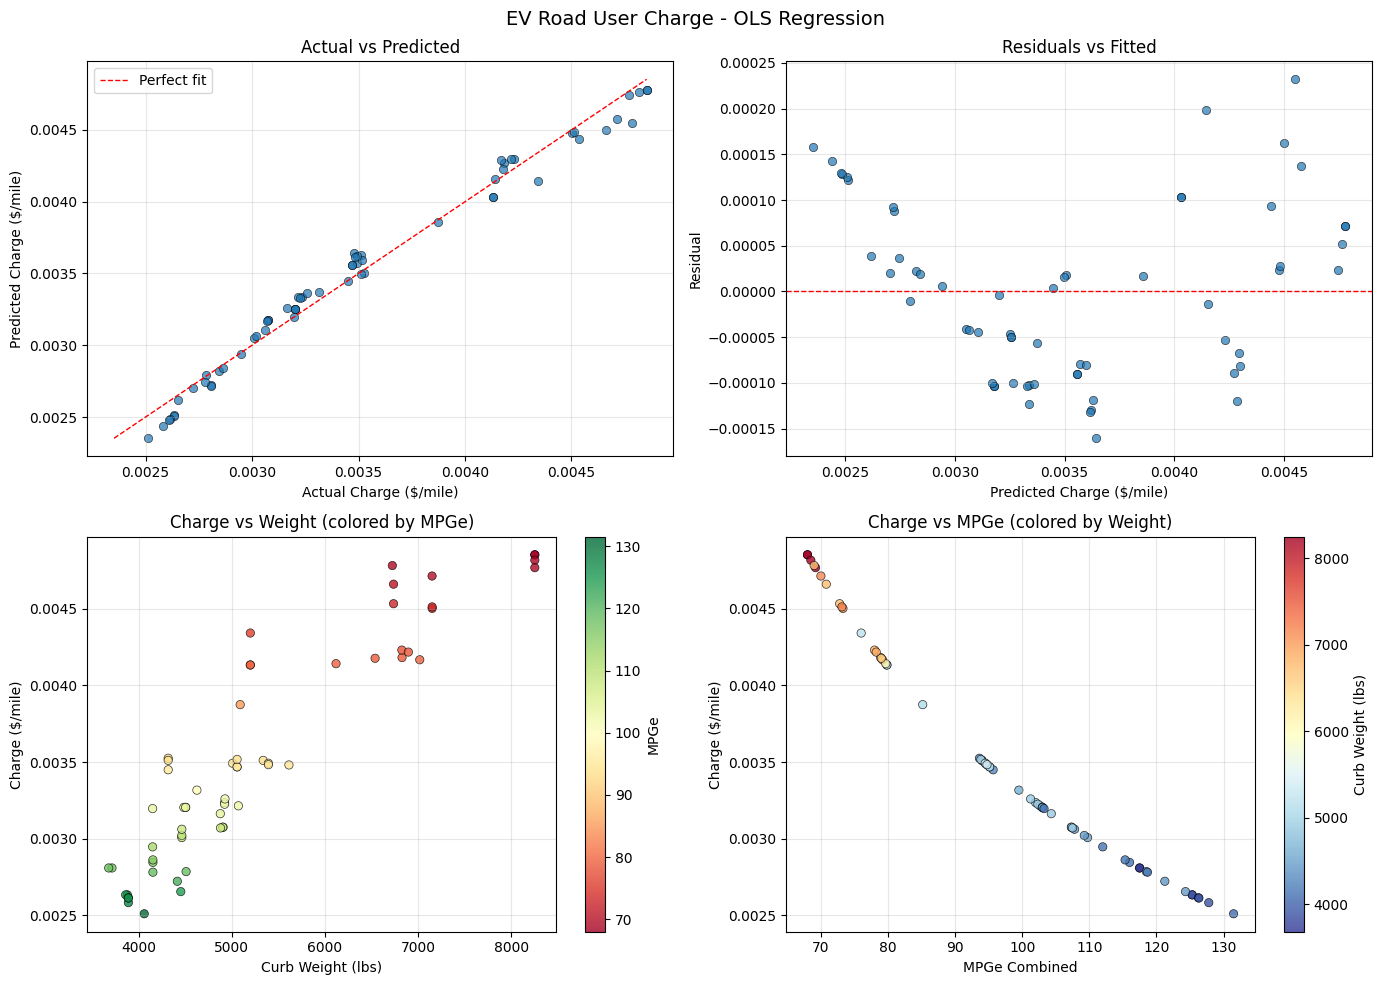

In [ ]:
# DIAGNOSTIC PLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EV Road User Charge - OLS Regression", fontsize=14)

# Plot 1: Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(final_df_with_mpge["charge_per_mile"], final_df_with_mpge["predicted_charge"],
            alpha=0.7, edgecolors="k", linewidths=0.5)
lims = [min(y.min(), final_df_with_mpge["predicted_charge"].min()),
        max(y.max(), final_df_with_mpge["predicted_charge"].max())]
ax1.plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
ax1.set_xlabel("Actual Charge ($/mile)")
ax1.set_ylabel("Predicted Charge ($/mile)")
ax1.set_title("Actual vs Predicted")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals vs Fitted
ax2 = axes[0, 1]
ax2.scatter(final_df_with_mpge["predicted_charge"], final_df_with_mpge["residual"],
            alpha=0.7, edgecolors="k", linewidths=0.5)
ax2.axhline(0, color="r", linestyle="--", linewidth=1)
ax2.set_xlabel("Predicted Charge ($/mile)")
ax2.set_ylabel("Residual")
ax2.set_title("Residuals vs Fitted")
ax2.grid(True, alpha=0.3)


# Plot 3: Charge per mile vs curb weight (colored by MPGe)
ax3 = axes[1, 0]
sc = ax3.scatter(final_df_with_mpge["curb_weight_lbs"], final_df_with_mpge["charge_per_mile"],
                 c=final_df_with_mpge["mpge_combined"], cmap="RdYlGn",
                 alpha=0.8, edgecolors="k", linewidths=0.5)
plt.colorbar(sc, ax=ax3, label="MPGe")
ax3.set_xlabel("Curb Weight (lbs)")
ax3.set_ylabel("Charge ($/mile)")
ax3.set_title("Charge vs Weight (colored by MPGe)")
ax3.grid(True, alpha=0.3)

# Plot 4: Charge per mile vs MPGe (colored by weight)
ax4 = axes[1, 1]
sc2 = ax4.scatter(final_df_with_mpge["mpge_combined"], final_df_with_mpge["charge_per_mile"],
                  c=final_df_with_mpge["curb_weight_lbs"], cmap="RdYlBu_r",
                  alpha=0.8, edgecolors="k", linewidths=0.5)
plt.colorbar(sc2, ax=ax4, label="Curb Weight (lbs)")
ax4.set_xlabel("MPGe Combined")
ax4.set_ylabel("Charge ($/mile)")
ax4.set_title("Charge vs MPGe (colored by Weight)")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("regression_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
#print("\nDiagnostic plots saved to regression_diagnostics.png")

In [ ]:
# KEY MODEL STATS
print("\n" + "=" * 60)
print("KEY MODEL STATISTICS")
print("=" * 60)
print(f"  R²:                {model.rsquared:.4f}")
print(f"  Adjusted R²:       {model.rsquared_adj:.4f}")
print(f"  F-statistic:       {model.fvalue:.2f}  (p = {model.f_pvalue:.4e})")
print(f"  AIC:               {model.aic:.2f}")
print(f"  Observations:      {int(model.nobs)}")
print()
print("  Coefficient p-values:")
for name, pval in model.pvalues.items():
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "(not significant)"
    print(f"    {name:25s}: p = {pval:.4e}  {sig}")


KEY MODEL STATISTICS
  R²:                0.9817
  Adjusted R²:       0.9810
  F-statistic:       1578.99  (p = 5.8940e-52)
  AIC:               -966.74
  Observations:      62

  Coefficient p-values:
    const                    : p = 6.0132e-32  ***
    curb_weight_lbs          : p = 3.5182e-08  ***
    mpge_combined            : p = 5.9435e-29  ***


In [ ]:
# CORRELATION CHECK
print("\n" + "=" * 60)
print("CORRELATION BETWEEN FEATURES")
print("=" * 60)
corr = final_df_with_mpge[["curb_weight_lbs", "mpge_combined", "charge_per_mile"]].corr()
print(corr.round(4))
print()
print("  Note: High correlation between curb_weight and mpge_combined")
print("  may indicate multicollinearity. Check VIF if concerned.")


CORRELATION BETWEEN FEATURES
                 curb_weight_lbs  mpge_combined  charge_per_mile
curb_weight_lbs           1.0000        -0.8804           0.9197
mpge_combined            -0.8804         1.0000          -0.9845
charge_per_mile           0.9197        -0.9845           1.0000

  Note: High correlation between curb_weight and mpge_combined
  may indicate multicollinearity. Check VIF if concerned.


In [ ]:
# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X_cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n  Variance Inflation Factors (VIF):")
print(vif_data.to_string(index=False))
print("  (VIF > 10 suggests problematic multicollinearity)")


  Variance Inflation Factors (VIF):
        feature     VIF
curb_weight_lbs 6.34604
  mpge_combined 6.34604
  (VIF > 10 suggests problematic multicollinearity)


Log model and comparison

In [ ]:
final_df_with_mpge["log_mpge"] = np.log(final_df_with_mpge["mpge_combined"])

In [ ]:
final_df_with_mpge["curb_weight_lbs"] = pd.to_numeric(final_df_with_mpge["curb_weight_lbs"], errors='coerce')

# Model 1: linear
X1 = sm.add_constant(final_df_with_mpge[["curb_weight_lbs", "mpge_combined"]])
m1 = sm.OLS(final_df_with_mpge["charge_per_mile"], X1, missing='drop').fit()

# Model 2: log-MPGe
X2 = sm.add_constant(final_df_with_mpge[["curb_weight_lbs", "log_mpge"]])
m2 = sm.OLS(final_df_with_mpge["charge_per_mile"], X2, missing='drop').fit()

final_df_with_mpge["pred_m1"] = m1.predict(X1)
final_df_with_mpge["pred_m2"] = m2.predict(X2)
final_df_with_mpge["resid_m1"] = final_df_with_mpge["charge_per_mile"] - final_df_with_mpge["pred_m1"]
final_df_with_mpge["resid_m2"] = final_df_with_mpge["charge_per_mile"] - final_df_with_mpge["pred_m2"]

In [ ]:
print("=" * 65)
print("MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Metric':<30} {'Model 1 (linear)':>16} {'Model 2 (log-MPGe)':>18}")
print("-" * 65)
print(f"{'R²':<30} {m1.rsquared:>16.4f} {m2.rsquared:>18.4f}")
print(f"{'Adjusted R²':<30} {m1.rsquared_adj:>16.4f} {m2.rsquared_adj:>18.4f}")
print(f"{'AIC':<30} {m1.aic:>16.2f} {m2.aic:>18.2f}")
print(f"{'BIC':<30} {m1.bic:>16.2f} {m2.bic:>18.2f}")
print(f"{'Durbin-Watson':<30} {sm.stats.durbin_watson(m1.resid):>16.3f} {sm.stats.durbin_watson(m2.resid):>18.3f}")
print(f"{'Max residual':<30} {final_df_with_mpge['resid_m1'].abs().max():>16.6f} {final_df_with_mpge['resid_m2'].abs().max():>18.6f}")
print(f"{'RMSE':<30} {np.sqrt((final_df_with_mpge['resid_m1']**2).mean()):>16.6f} {np.sqrt((final_df_with_mpge["resid_m2"]**2).mean()):>18.6f}")
print()

MODEL COMPARISON SUMMARY
Metric                         Model 1 (linear) Model 2 (log-MPGe)
-----------------------------------------------------------------
R²                                       0.9817             0.9945
Adjusted R²                              0.9810             0.9943
AIC                                     -966.74           -1041.78
BIC                                     -960.36           -1035.40
Durbin-Watson                             0.992              1.013
Max residual                           0.000232           0.000121
RMSE                                   0.000095           0.000052



In [ ]:
print("=" * 65)
print("MODEL 1: charge ~ weight + MPGe  (linear)")
print("=" * 65)
print(m1.summary())

print("\n" + "=" * 65)
print("MODEL 2: charge ~ weight + log(MPGe)")
print("=" * 65)
print(m2.summary())

MODEL 1: charge ~ weight + MPGe  (linear)
                            OLS Regression Results                            
Dep. Variable:        charge_per_mile   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     1579.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           5.89e-52
Time:                        02:31:40   Log-Likelihood:                 486.37
No. Observations:                  62   AIC:                            -966.7
Df Residuals:                      59   BIC:                            -960.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------


In [ ]:
# FORMULAS
print("\n" + "=" * 65)
print("ESTIMATED FORMULAS")
print("=" * 65)

print("\nModel 1 (linear MPGe):")
print(f"  charge_per_mile = {m1.params['const']:.6f}")
print(f"                  + {m1.params['curb_weight_lbs']:.8f} × curb_weight_lbs")
print(f"                  + {m1.params['mpge_combined']:.6f} × mpge_combined")

print("\nModel 2 (log MPGe):")
print(f"  charge_per_mile = {m2.params['const']:.6f}")
print(f"                  + {m2.params['curb_weight_lbs']:.8f} × curb_weight_lbs")
print(f"                  + {m2.params['log_mpge']:.6f} × log(mpge_combined)")

print("\n  (multiply charge_per_mile by 100 for cents per mile)")


ESTIMATED FORMULAS

Model 1 (linear MPGe):
  charge_per_mile = 0.005709
                  + 0.00000013 × curb_weight_lbs
                  + -0.000030 × mpge_combined

Model 2 (log MPGe):
  charge_per_mile = 0.017972
                  + 0.00000006 × curb_weight_lbs
                  + -0.003238 × log(mpge_combined)

  (multiply charge_per_mile by 100 for cents per mile)


In [ ]:
# VIF FOR BOTH MODELS
print("\n" + "=" * 65)
print("VIF COMPARISON")
print("=" * 65)

features_m1 = ["curb_weight_lbs", "mpge_combined"]
features_m2 = ["curb_weight_lbs", "log_mpge"]
X1_raw = final_df_with_mpge[features_m1]
X2_raw = final_df_with_mpge[features_m2]

print(f"\n{'Feature':<25} {'VIF (Model 1)':>14} {'VIF (Model 2)':>14}")
print("-" * 54)
for i, (f1, f2) in enumerate(zip(features_m1, features_m2)):
    v1 = variance_inflation_factor(X1_raw.values, i)
    v2 = variance_inflation_factor(X2_raw.values, i)
    print(f"{f1:<25} {v1:>14.4f} {f2:>14}  {v2:.4f}")


VIF COMPARISON

Feature                    VIF (Model 1)  VIF (Model 2)
------------------------------------------------------
curb_weight_lbs                   6.3460 curb_weight_lbs  13.7186
mpge_combined                     6.3460       log_mpge  13.7186


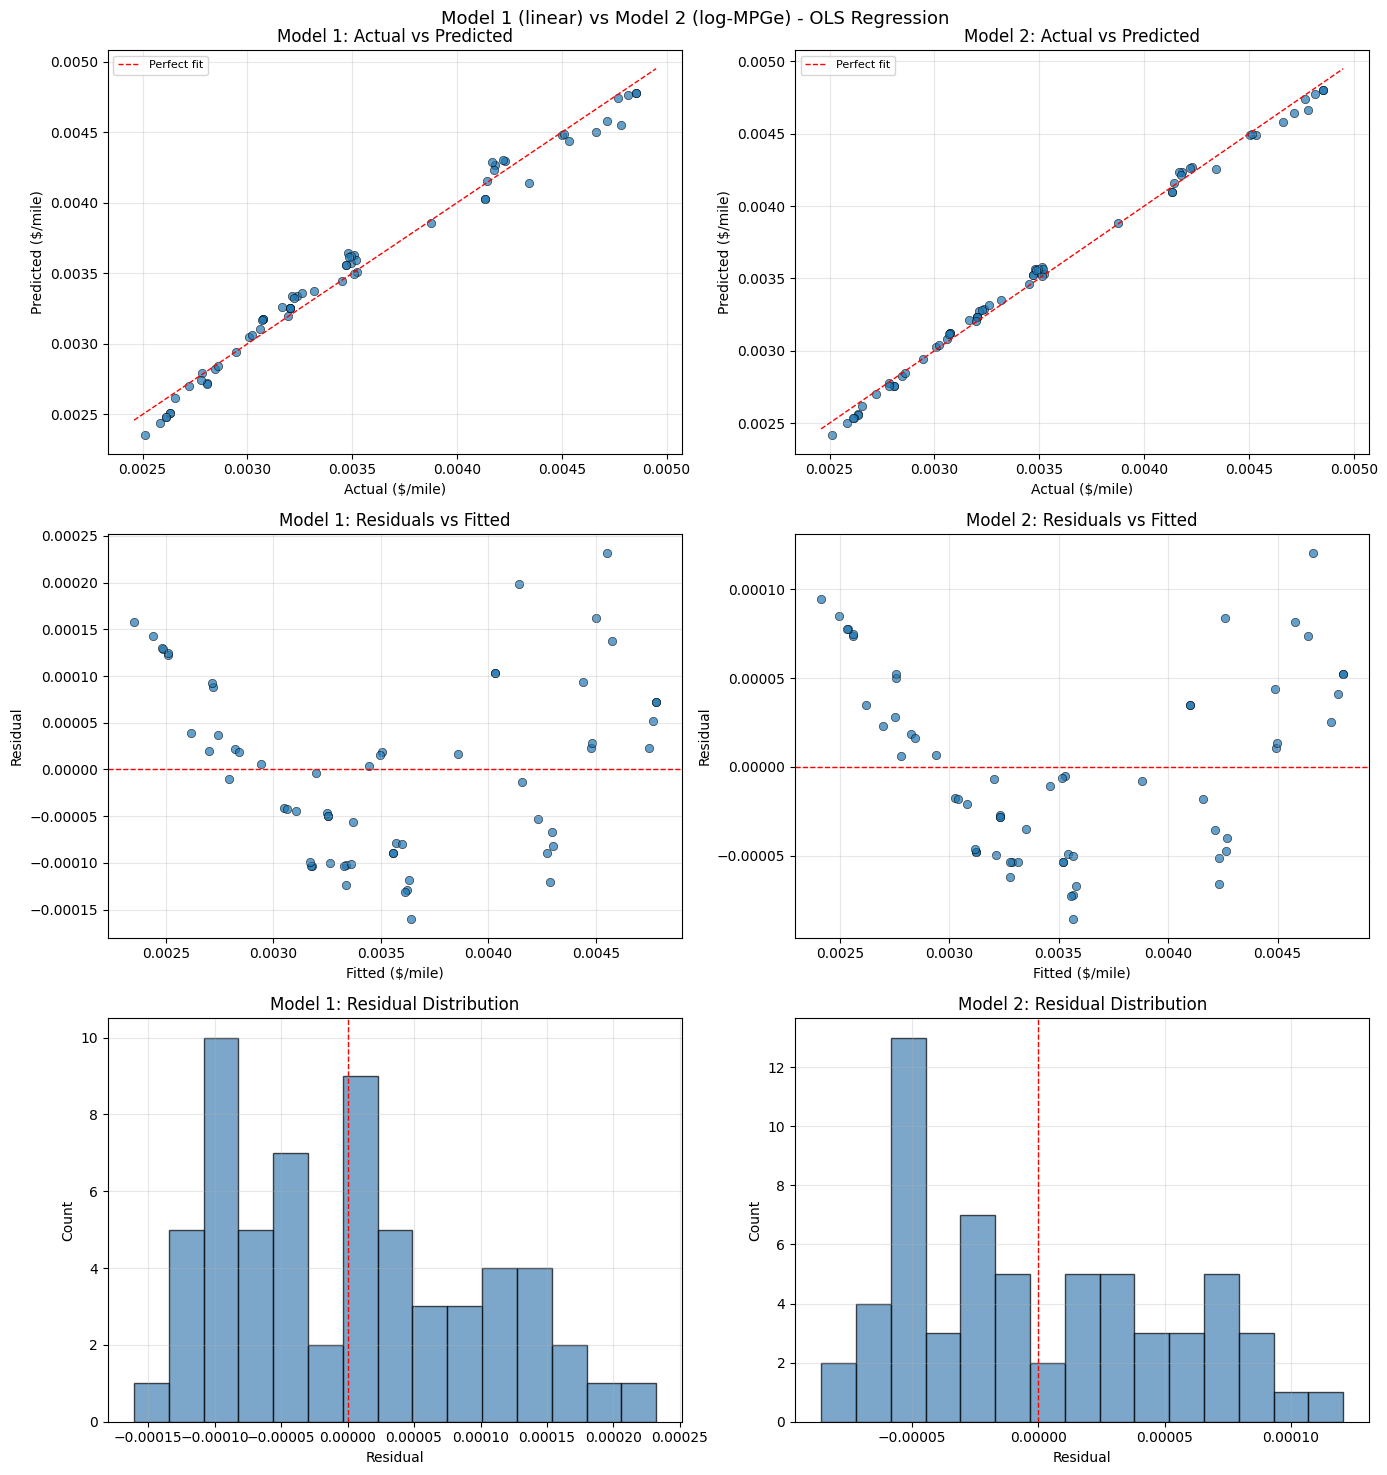

In [ ]:
# DIAGNOSTIC PLOTS
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Model 1 (linear) vs Model 2 (log-MPGe) - OLS Regression" , fontsize=13)

# Row 1: Actual vs Predicted
for ax, pred_col, title in zip(
    axes[0],
    ["pred_m1", "pred_m2"],
    ["Model 1: Actual vs Predicted", "Model 2: Actual vs Predicted"]
):
    ax.scatter(final_df_with_mpge["charge_per_mile"], final_df_with_mpge[pred_col],
               alpha=0.7, edgecolors="k", linewidths=0.5)
    lims = [final_df_with_mpge["charge_per_mile"].min() * 0.98,
            final_df_with_mpge["charge_per_mile"].max() * 1.02]
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
    ax.set_xlabel("Actual ($/mile)")
    ax.set_ylabel("Predicted ($/mile)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Row 2: Residuals vs Fitted
for ax, pred_col, resid_col, title in zip(
    axes[1],
    ["pred_m1", "pred_m2"],
    ["resid_m1", "resid_m2"],
    ["Model 1: Residuals vs Fitted", "Model 2: Residuals vs Fitted"]
):
    ax.scatter(final_df_with_mpge[pred_col], final_df_with_mpge[resid_col],
               alpha=0.7, edgecolors="k", linewidths=0.5)
    ax.axhline(0, color="r", linestyle="--", linewidth=1)
    ax.set_xlabel("Fitted ($/mile)")
    ax.set_ylabel("Residual")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Row 3: Residual distributions
for ax, resid_col, title in zip(
    axes[2],
    ["resid_m1", "resid_m2"],
    ["Model 1: Residual Distribution", "Model 2: Residual Distribution"]
):
    ax.hist(final_df_with_mpge[resid_col], bins=15, edgecolor="k", alpha=0.7, color="steelblue")
    ax.axvline(0, color="r", linestyle="--", linewidth=1)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("regression_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
#print("\nComparison plots saved to regression_model_comparison.png")

In [ ]:
#saving df as csv
final_df_with_mpge.to_csv("final_df_with_mpge.csv", index=False)